# LabSheet 12 - Development of Neural Network (forward and backward propagation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sigmoid activation function
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return x * (1 - x)

In [3]:
# Initialize the datset (X: Inputs, y: Outputs)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

## Network Structure and Hyperparameters

In [4]:
# Hyperparameters
input_neurons = X.shape[1] # Number of input features (2)
hidden_neurons = 4 # Number neurons in the hidden layer
output_neurons = 1 # Output layer (binary classification)
learning_rate = 0.1
epochs = 10000

## Weight and Bias Initialization

In [5]:
np.random.seed(42)
W1 = np.random.uniform(-1, 1, (input_neurons, hidden_neurons)) # Weights for input to hidden layer
b1 = np.zeros((1, hidden_neurons)) # Bias for hidden layer
W2 = np.random.uniform(-1, 1, (hidden_neurons, output_neurons)) # Weights for hidden to output layer
b2 = np.zeros((1, output_neurons)) # Bias for output layer

## Forward pass & Loss Calculation & Backpropagation & Weights updates

In [6]:
# Store loss values for visualization
losses = []

# Training loop
for epoch in range(epochs):
  # Forward pass
  Z1 = np.dot(X, W1) + b1 # Input to hidden layer
  A1 = sigmoid(Z1) # Activation of hidden layer
  Z2 = np.dot(A1, W2) + b2 # Input to output layer
  A2 = sigmoid(Z2) # Activation of output layer (predicted output)

  # Compute loss (Mean Squared Error)
  loss = np.mean((A2 - y) ** 2)
  losses.append(loss)

  # Backward pass
  dA2 = -(y - A2) # Derivative of loss w.r.t. output
  dZ2 = dA2 * sigmoid_derivative(A2) # Derivative of output layer activation
  dW2 = np.dot(A1.T, dZ2) # Gradient for W2
  db2 = np.sum(dZ2, axis=0, keepdims=True) # Gradient for b2

  dA1 = np.dot(dZ2, W2.T) # Backpropagated error to hidden layer
  dZ1 = dA1 * sigmoid_derivative(A1) # Derivative of hidden layer activation
  dW1 = np.dot(X.T, dZ1) # Gradient for W1
  db1 = np.sum(dZ1, axis=0, keepdims=True) # Gradient for b1

  # Update weights and biases
  W2 -= learning_rate * dW2
  b2 -= learning_rate * db2
  W1 -= learning_rate * dW1
  b1 -= learning_rate * db1

  # Print loss at intervals
  if epoch % 1000 == 0:
    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.26291577441910563
Epoch 1000, Loss: 0.24010925317841741
Epoch 2000, Loss: 0.11315047302007028
Epoch 3000, Loss: 0.02238492959033772
Epoch 4000, Loss: 0.009683919491691334
Epoch 5000, Loss: 0.005845492291370796
Epoch 6000, Loss: 0.0041005242854049865
Epoch 7000, Loss: 0.0031259876184237053
Epoch 8000, Loss: 0.0025110690063937075
Epoch 9000, Loss: 0.0020905738364353616


# Show the results

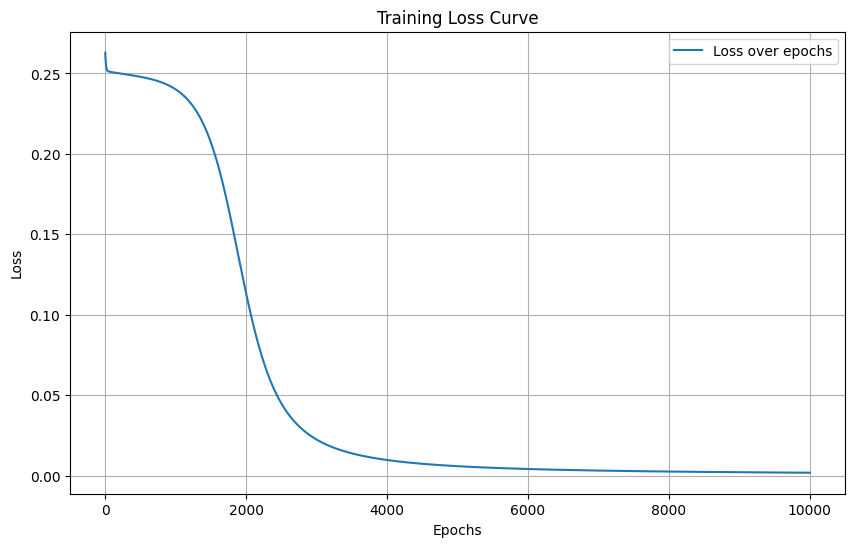


Final predictions
Input: [0 0], Predicted: 0.0278, Actual: 0
Input: [0 1], Predicted: 0.9565, Actual: 1
Input: [1 0], Predicted: 0.9583, Actual: 1
Input: [1 1], Predicted: 0.0524, Actual: 0

Predicted Classes:
Input: [0 0], Predicted Class: 0, Actual Class: 0
Input: [0 1], Predicted Class: 1, Actual Class: 1
Input: [1 0], Predicted Class: 1, Actual Class: 1
Input: [1 1], Predicted Class: 0, Actual Class: 0


In [7]:
# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses, label="Loss over epochs")
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Testing the trained model
print("\nFinal predictions")
A1 = sigmoid(np.dot(X, W1) + b1)
A2 = sigmoid(np.dot(A1, W2) + b2)

# Display predictions
for i in range(len(X)):
  print(f"Input: {X[i]}, Predicted: {A2[i][0]:.4f}, Actual: {y[i][0]}")

# Classify predictions (round to nearest integer)
predicted_classes = (A2 > 0.5).astype(int)
print("\nPredicted Classes:")
for i in range(len(X)):
  print(f"Input: {X[i]}, Predicted Class: {predicted_classes[i][0]}, Actual Class: {y[i][0]}")